# Forest cover & loss per Ethnologue polygon — FIXED version

Re-does the calculation in [`forestloss_ethnologue.ipynb`](forestloss_ethnologue.ipynb) with two corrections:

**1. Correct km² conversion with latitude-aware pixel area.**
The merged mosaic is in EPSG:4326 at `res=(0.01°, 0.01°)`. Each pixel is ~1 km×1 km *only near the equator* — it shrinks with `cos(latitude)` toward the poles. The original code multiplied pixel counts by `0.01` (the km² of a 100 m pixel, not a 0.01° pixel), so every number was off by ~100× and additionally biased by latitude. Here we compute each cell's actual km² from its latitude and sum those areas.

**2. Keep fractional loss values instead of truncating with `astype(np.uint8)`.**
Hansen `loss` is binary 0/1 at native 30m, but `merge(..., resampling=Resampling.average)` aggregated it to ~1km, producing fractional values in `[0, 1]` = *share of sub-pixels that were lost*. The original cast to `uint8` sent everything <1.0 to 0, which discards nearly all real loss signal. Here we keep the fractions.

**Forest definition (matches `forestloss_ethnologue.ipynb`):** a cell counts as forest if its (averaged) `treecover2000 > 30%` — the standard Hansen ≥30% canopy convention.

**Resulting measures:**
- `treecover_km2` = sum of `cell_area_km2` over cells where `treecover > 30%` = km² of forest in the polygon.
- `treeloss_km2` = sum over cells of `(loss_frac × cell_area_km2)` = km² of forest-loss-equivalent area in the polygon (cumulative 2001–2024), kept continuous.

In [2]:
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterstats import zonal_stats

import matplotlib.pyplot as plt
from rasterio.plot import show

In [3]:
base_path = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")
poscol_path = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"
hansen_path = base_path / "maps" / "raw" / "Hansen_forest"

ethnologue = gpd.read_file(poscol_path)
ethnologue = ethnologue[["ID", "geometry"]]
print(f"Number of features: {len(ethnologue)}")

Number of features: 7087


In [4]:
# --- Helpers ---------------------------------------------------------------
def mosaic_1km(folder: Path):
    """Merge all .tif tiles in `folder` to ~1km resolution using average resampling."""
    files = sorted(glob(str(folder / "*.tif")))
    srcs  = [rasterio.open(fp) for fp in files]
    mos, trans = merge(srcs, res=(0.01, 0.01), resampling=Resampling.average)
    crs = srcs[0].crs
    for s in srcs:
        s.close()
    return mos[0].astype(np.float32), trans, crs

def pixel_area_km2_grid(transform, shape):
    """Build a (rows, cols) array of per-cell area in km² given an EPSG:4326 transform.

    Uses the spherical-Earth approximation: cell area at latitude φ is
        (R * dλ * cosφ) * (R * dφ)
    with dλ, dφ in radians. Accurate to <0.3% for a sphere; good enough here.
    """
    rows, cols = shape
    R_km  = 6371.0088
    dlat  = abs(transform.e)  # pixel height in degrees (negative in north-up)
    dlon  = abs(transform.a)  # pixel width  in degrees
    # Latitude of each row center
    lat_top = transform.f
    lat_centers = lat_top + (np.arange(rows) + 0.5) * transform.e   # transform.e is negative
    lat_rad = np.deg2rad(lat_centers)
    dy_km = R_km * np.deg2rad(dlat)                                 # constant per row (sphere)
    dx_km = R_km * np.cos(lat_rad) * np.deg2rad(dlon)               # shrinks with latitude
    area_row = (dx_km * dy_km).astype(np.float32)                   # (rows,)
    return np.broadcast_to(area_row[:, None], (rows, cols)).astype(np.float32)

def zonal_sum_on_array(array, transform, crs, polygons):
    """Write a float32 array to an in-memory GeoTIFF and zonal-sum it over `polygons`."""
    with MemoryFile() as mf:
        with mf.open(
            driver="GTiff",
            height=array.shape[0],
            width=array.shape[1],
            count=1,
            dtype="float32",
            transform=transform,
            crs=crs,
            nodata=np.float32(-9999.0),
        ) as dst:
            arr = np.where(np.isnan(array), np.float32(-9999.0), array).astype(np.float32)
            dst.write(arr, 1)
        stats = zonal_stats(polygons, mf.name, stats=["sum"], geojson_out=True)
    return [s["properties"]["sum"] for s in stats]

treecover shape: (17000, 36000) | crs: EPSG:4326


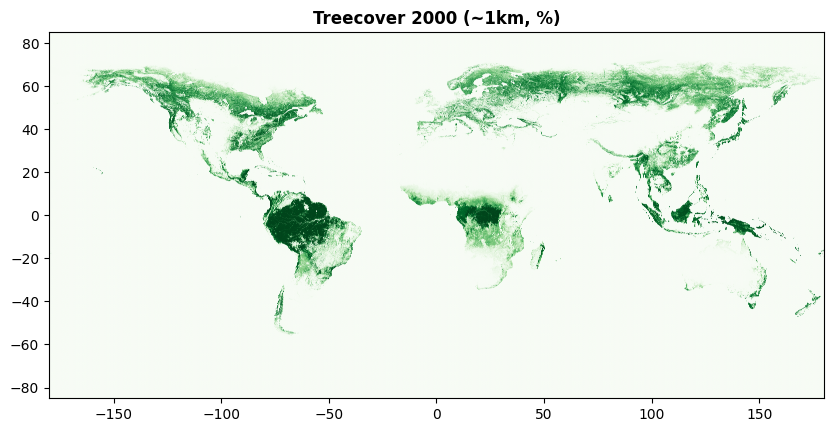

In [5]:
# --- Build treecover mosaic (values 0–100 = % tree cover) ------------------
treecover, tc_trans, tc_crs = mosaic_1km(hansen_path / "treecover")
print("treecover shape:", treecover.shape, "| crs:", tc_crs)

ethnologue = ethnologue.to_crs(tc_crs)

fig, ax = plt.subplots(figsize=(10, 5))
show(treecover, transform=tc_trans, ax=ax, title="Treecover 2000 (~1km, %)", cmap="Greens")
plt.show()

In [6]:
# --- Build treeloss mosaic (values 0–1 = fraction of sub-pixels lost) -------
treeloss, tl_trans, tl_crs = mosaic_1km(hansen_path / "treeloss")
print("treeloss shape:", treeloss.shape, "| crs:", tl_crs)

# Sanity: treeloss mosaic should have the same grid as treecover
assert treecover.shape == treeloss.shape, "treecover and treeloss mosaics have different shapes"
assert tc_trans == tl_trans, "treecover and treeloss mosaics have different transforms"

treeloss shape: (17000, 36000) | crs: EPSG:4326


In [7]:
# --- Per-cell area in km² (latitude-aware) ---------------------------------
area_km2 = pixel_area_km2_grid(tc_trans, treecover.shape)
print("area_km2 range:", float(area_km2.min()), "-", float(area_km2.max()), "| mean:", float(area_km2.mean()))

area_km2 range: 0.10786937177181244 - 1.2364345788955688 | mean: 0.8302695155143738


In [8]:
# --- Weighted rasters: km² of forest / loss per cell ----------------------
# treecover: 0–100 (%)   → forest mask = treecover > 30 (Hansen convention, matches forestloss_ethnologue.ipynb)
# treeloss : 0–1 already → use directly as fraction
forest_mask = (treecover > 30).astype(np.float32)
loss_frac   = np.clip(treeloss, 0.0, 1.0).astype(np.float32)

cover_km2_cell = (forest_mask * area_km2).astype(np.float32)
loss_km2_cell  = (loss_frac   * area_km2).astype(np.float32)

print("Global totals (sanity) — cover:",
      float(cover_km2_cell.sum()) / 1e6, "M km² | loss:",
      float(loss_km2_cell.sum())  / 1e6, "M km²")

Global totals (sanity) — cover: 41.545356 M km² | loss: 4.651079 M km²


In [9]:
# --- Zonal sums --------------------------------------------------------------
ethnologue["treecover_km2"] = zonal_sum_on_array(cover_km2_cell, tc_trans, tc_crs, ethnologue)
ethnologue["treeloss_km2"]  = zonal_sum_on_array(loss_km2_cell,  tc_trans, tc_crs, ethnologue)

ethnologue[["ID", "treecover_km2", "treeloss_km2"]].head()

,ID,treecover_km2,treeloss_km2
0,RUS-RUS,4.465460e+06,353751.500000
1,ENG-USA,2.595250e+06,341619.312500
2,POR-BRA,3.804592e+06,574434.562500
3,ENG-AUS,3.395979e+05,97067.242188
4,CMN-CHN,6.666867e+05,7944.387695


In [10]:
df = ethnologue[["ID", "treecover_km2", "treeloss_km2"]]
print(len(df))
df.describe()

7087


,treecover_km2,treeloss_km2
count,7.056000e+03,7056.000000
mean,4.928116e+03,529.664638
std,8.106604e+04,10115.399814
min,0.000000e+00,0.000000
25%,1.224252e+01,0.000000
50%,1.859384e+02,0.000000
75%,1.147394e+03,26.889092
max,4.465460e+06,574434.562500


In [11]:
out_path = hansen_path / "ethnologue_treecoverloss_fixed.csv"
df.to_csv(out_path, index=False)
print("Exported", out_path)

Exported C:\Users\juami\Dropbox\RAships\2-Folklore-Nathan-Project\EA-Maps-Nathan-project\Measures_work\maps\raw\Hansen_forest\ethnologue_treecoverloss_fixed.csv
